# Airbnb New User Bookings — EDA
Following `docs/eda_checklist.md`.

Core table: `train_users_2` (user + target `country_destination`). Supporting: `sessions` (action log), `age_gender_bkts`, `countries`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

DATA_DIR = "../../data/raw/hospitality/airbnb_new_user"
sns.set_theme(style="whitegrid")

## 1. Load & Overview

In [2]:
users = pd.read_csv(f"{DATA_DIR}/train_users_2.csv")
sessions = pd.read_csv(f"{DATA_DIR}/sessions.csv")
countries = pd.read_csv(f"{DATA_DIR}/countries.csv")
age_buckets = pd.read_csv(f"{DATA_DIR}/age_gender_bkts.csv")

for name, df in [("users", users), ("sessions", sessions), ("countries", countries), ("age_buckets", age_buckets)]:
    print(name, df.shape)

users (213451, 16)
sessions (10567737, 6)
countries (10, 7)
age_buckets (420, 5)


In [3]:
users.head()

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US


In [4]:
users.dtypes

id                             str
date_account_created           str
timestamp_first_active       int64
date_first_booking             str
gender                         str
age                        float64
signup_method                  str
signup_flow                  int64
language                       str
affiliate_channel              str
affiliate_provider             str
first_affiliate_tracked        str
signup_app                     str
first_device_type              str
first_browser                  str
country_destination            str
dtype: object

## 2. Missing Values

In [5]:
(users.isna().mean() * 100).round(1).sort_values(ascending=False)

date_first_booking         58.3
age                        41.2
first_affiliate_tracked     2.8
date_account_created        0.0
timestamp_first_active      0.0
gender                      0.0
signup_method               0.0
id                          0.0
signup_flow                 0.0
language                    0.0
affiliate_channel           0.0
affiliate_provider          0.0
signup_app                  0.0
first_device_type           0.0
first_browser               0.0
country_destination         0.0
dtype: float64

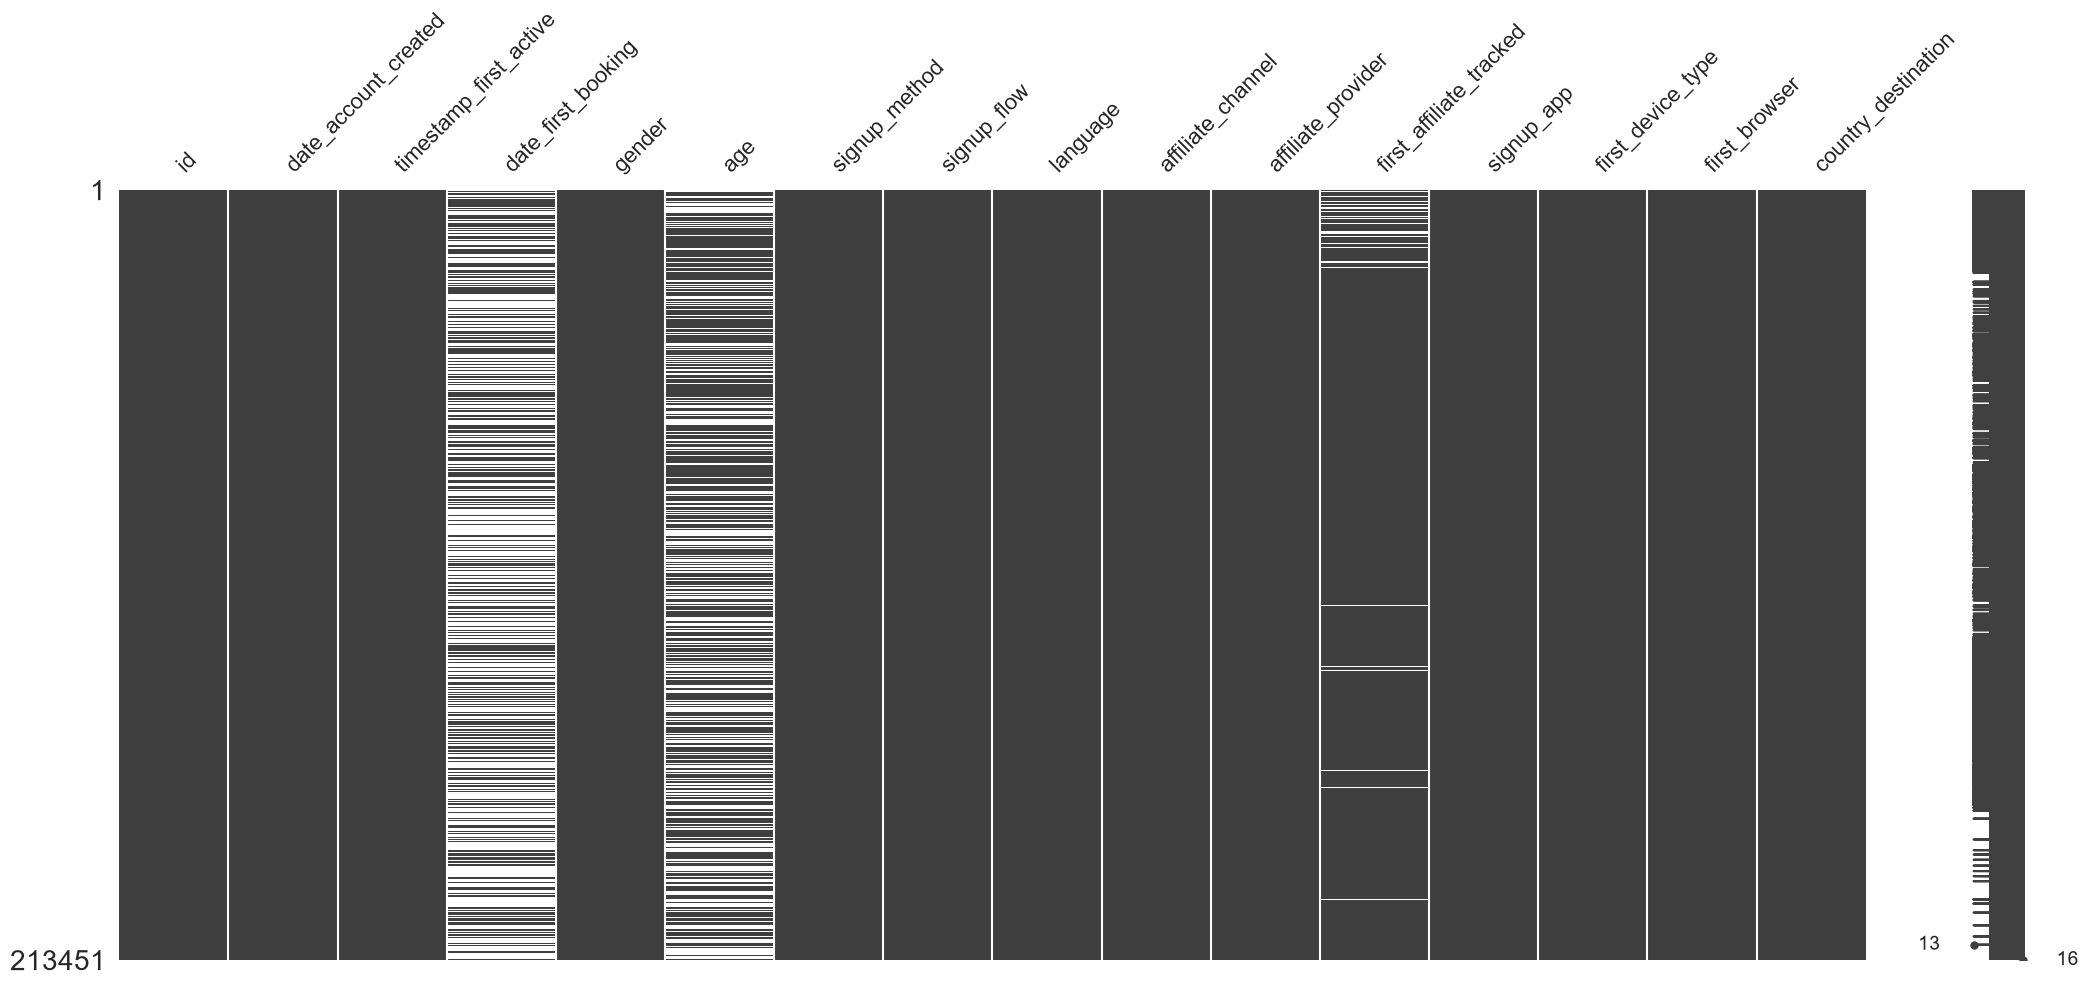

In [6]:
msno.matrix(users); plt.show()

Decision: `date_first_booking` missing should align with `country_destination == NDF` (never booked) — verify in section 9, not a real gap if so. `age`/`first_affiliate_tracked`/`gender` genuinely missing — flag, impute or model as own category.

## 3. Duplicates

In [7]:
print("full-row dup users:", users.duplicated().sum())
print("dup id:", users.duplicated(subset=["id"]).sum())

full-row dup users: 0
dup id: 0


## 4. Univariate Analysis

In [8]:
users["age"].describe()

count    125461.000000
mean         49.668335
std         155.666612
min           1.000000
25%          28.000000
50%          34.000000
75%          43.000000
max        2014.000000
Name: age, dtype: float64

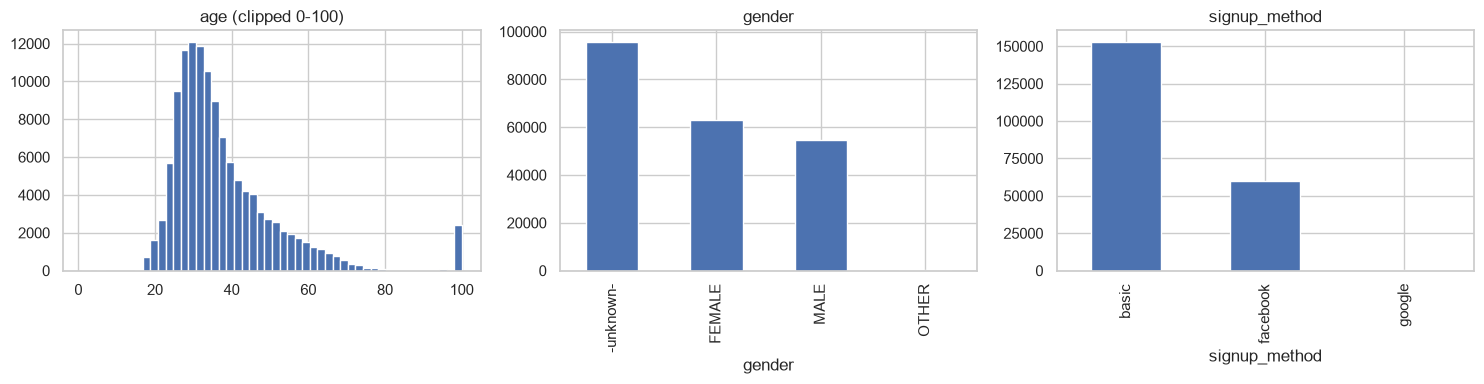

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
users["age"].clip(0, 100).hist(bins=50, ax=ax[0]); ax[0].set_title("age (clipped 0-100)")
users["gender"].value_counts(dropna=False).plot(kind="bar", ax=ax[1]); ax[1].set_title("gender")
users["signup_method"].value_counts().plot(kind="bar", ax=ax[2]); ax[2].set_title("signup_method")
plt.tight_layout(); plt.show()

## 5. Outliers

In [10]:
print("age > 100:", (users["age"] > 100).sum())
print("age > 1000 (year typo suspects):", (users["age"] > 1000).sum())
print("age < 14:", (users["age"] < 14).sum())
print("age max:", users["age"].max(), "| age min:", users["age"].min())

age > 100: 2345
age > 1000 (year typo suspects): 779
age < 14: 57
age max: 2014.0 | age min: 1.0


Decision: known Airbnb dataset quirk — some `age` values are entered as birth year (e.g. 2014, 1995) instead of actual age. Flag and clean (`age > 100` or `age < 14` -> treat as missing/invalid, don't use raw).

## 6. Target Variable

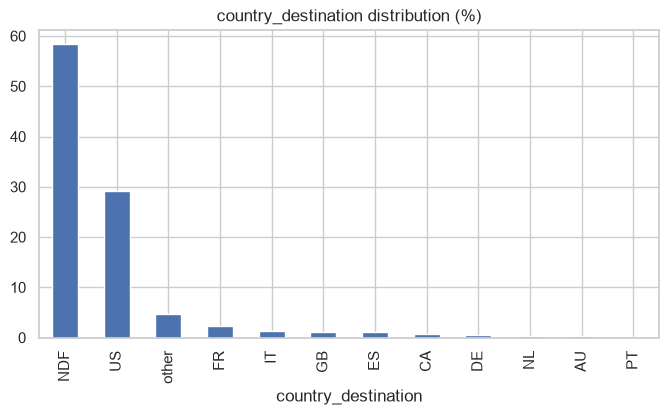

country_destination
NDF      58.347349
US       29.222632
other     4.728954
FR        2.353233
IT        1.328174
GB        1.088774
ES        1.053638
CA        0.669006
DE        0.497070
NL        0.356991
AU        0.252517
PT        0.101663
Name: proportion, dtype: float64

In [11]:
dest_counts = users["country_destination"].value_counts(normalize=True) * 100
dest_counts.plot(kind="bar", figsize=(8, 4), title="country_destination distribution (%)")
plt.show()
dest_counts

Heavy class imbalance: `NDF` (no booking) dominates — need resampling/weighting or treat as two-stage task (book vs not, then which country) later.

## 7. Bivariate / Correlation Analysis

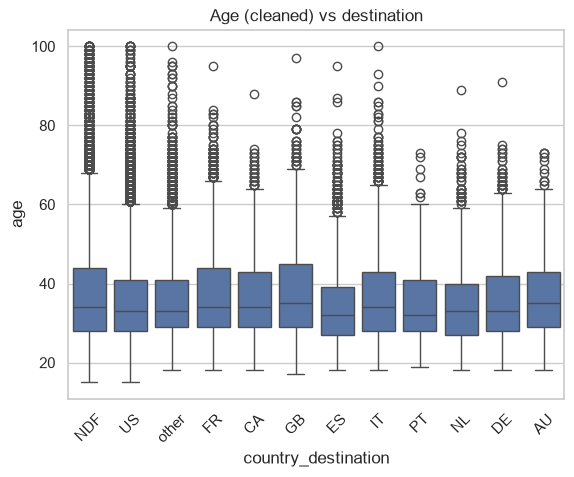

In [12]:
clean_age = users["age"].where(users["age"].between(14, 100))
sns.boxplot(x=users["country_destination"], y=clean_age)
plt.title("Age (cleaned) vs destination"); plt.xticks(rotation=45); plt.show()

In [13]:
pd.crosstab(users["signup_method"], users["country_destination"], normalize="index").round(3)

country_destination,AU,CA,DE,ES,FR,GB,IT,NDF,NL,PT,US,other
signup_method,,,,,,,,,,,,
basic,0.003,0.007,0.005,0.010,0.025,0.011,0.014,0.575,0.004,0.001,0.297,0.049
facebook,0.002,0.005,0.005,0.011,0.021,0.010,0.011,0.604,0.003,0.001,0.281,0.044
google,0.000,0.002,0.002,0.004,0.005,0.000,0.004,0.815,0.000,0.002,0.145,0.022


## 8. Time-based Checks

account_created range: 2010-01-01 00:00:00 to 2014-06-30 00:00:00
first_active range: 2009-03-19 04:32:55 to 2014-06-30 23:58:24


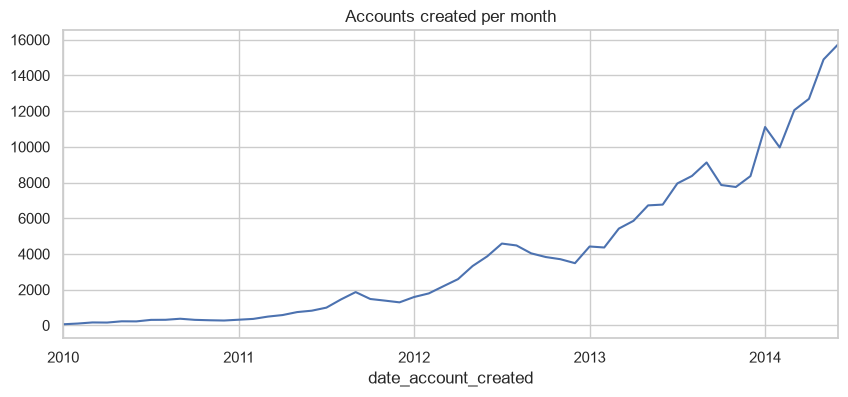

In [14]:
users["date_account_created"] = pd.to_datetime(users["date_account_created"])
users["timestamp_first_active"] = pd.to_datetime(users["timestamp_first_active"], format="%Y%m%d%H%M%S")
print("account_created range:", users["date_account_created"].min(), "to", users["date_account_created"].max())
print("first_active range:", users["timestamp_first_active"].min(), "to", users["timestamp_first_active"].max())
users.set_index("date_account_created").resample("ME").size().plot(figsize=(10, 4), title="Accounts created per month")
plt.show()

## 9. Data Consistency

In [15]:
ndf_missing_booking = users.loc[users["country_destination"] == "NDF", "date_first_booking"].isna().mean()
non_ndf_missing_booking = users.loc[users["country_destination"] != "NDF", "date_first_booking"].isna().mean()
print(f"NDF rows missing date_first_booking: {ndf_missing_booking:.2%}")
print(f"non-NDF rows missing date_first_booking: {non_ndf_missing_booking:.2%}")
print("session user_id not in train users:", (~sessions["user_id"].isin(users["id"])).mean())

NDF rows missing date_first_booking: 100.00%
non-NDF rows missing date_first_booking: 0.00%


session user_id not in train users: 0.47595620519322157


## 10. Feature Relationships for Recommendation Context
Target itself is a next-best-destination pick (12-way) — natural fit for this project. Also check session-action coverage as secondary interaction signal.

In [16]:
n_users_with_sessions = sessions["user_id"].nunique()
print(f"users in train: {len(users)} | users with any session log: {n_users_with_sessions} | coverage: {n_users_with_sessions/len(users):.1%}")
action_counts = sessions["action"].value_counts()
print("top actions:\n", action_counts.head(10))

users in train: 213451 | users with any session log: 135483 | coverage: 63.5%


top actions:
 action
show                     2768278
index                     843699
search_results            725226
personalize               706824
search                    536057
ajax_refresh_subtotal     487744
update                    365130
similar_listings          364624
social_connections        339000
reviews                   320591
Name: count, dtype: int64


booked users=88908 distinct destinations=11


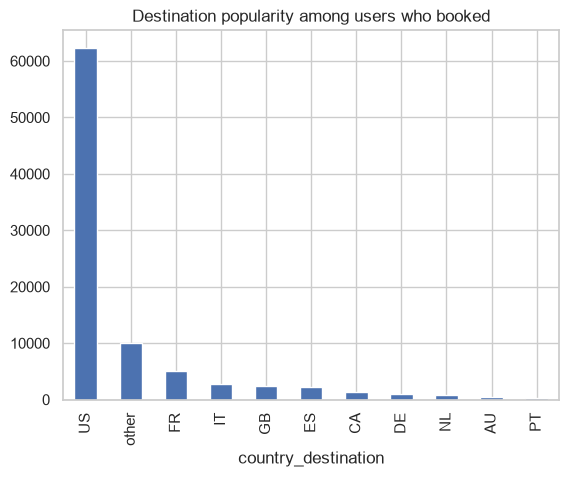

In [17]:
booked_mask = users["country_destination"] != "NDF"
n_dest = users.loc[booked_mask, "country_destination"].nunique()
dest_pop = users.loc[booked_mask, "country_destination"].value_counts()
print(f"booked users={booked_mask.sum()} distinct destinations={n_dest}")
dest_pop.plot(kind="bar", title="Destination popularity among users who booked"); plt.show()

## 11. Summary

- Shape: 213,451 users (train), 10.6M session-log rows, 10 destination countries + NDF/other.
- Missing: `date_first_booking` gap = 58.3% overall, confirmed exactly structural — 100% missing when `NDF`, 0% missing otherwise. `age` 41.2% missing, `first_affiliate_tracked` 2.8% missing — both genuine gaps, need own-category treatment.
- No duplicate `id` rows.
- Known quirk confirmed: `age` contains birth-year-typo values — max value 2014, 2345 rows >100, 779 rows >1000, 57 rows <14. Must clean before use.
- Target `country_destination` heavily imbalanced: NDF 58.3%, US 29.2%, everything else <5% each — consider two-stage model (booked vs not, then destination) instead of single 12-way classifier.
- `sessions.csv` covers only 63.5% of train users (135,483 / 213,451) — real coverage gap, not usable as universal feature. Also 47.6% of session rows have a `user_id` NOT present in train_users_2 (extra/unlinked users, likely test-set or orphaned) — join carefully, don't assume 1:1.
- Destination popularity among the 88,908 users who did book is itself long-tail (US dominant, 11 distinct destinations) — matches typical rec-system popularity bias even in a small-cardinality target.
- Strong direct fit for this project: `country_destination` prediction IS a next-best-item (destination) recommendation task, closest conceptually to Akeed among all datasets pulled.